In [8]:
import numpy as np
import pandas as p
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [9]:
Data = p.read_csv('../data/student_marks.csv')
dataset = Data
dataset

,study_hours,Attendance,Assgnment_Score,Final_marks
0,2,60,50,42
1,3,65,55,48
2,4,70,58,54
3,5,75,65,61
4,6,80,70,67
5,7,85,74,73
6,8,90,80,81
7,9,95,88,89


In [10]:
x=dataset.iloc[:, 0:3].values
x

array([[ 2, 60, 50],
       [ 3, 65, 55],
       [ 4, 70, 58],
       [ 5, 75, 65],
       [ 6, 80, 70],
       [ 7, 85, 74],
       [ 8, 90, 80],
       [ 9, 95, 88]])

In [11]:
y = dataset.iloc[:, -1].values
y

array([42, 48, 54, 61, 67, 73, 81, 89])

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 45)

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.12,0.61,0.66]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-28.33
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[44.98, 1.48, 0. ]"


In [14]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_)

Intercept: -28.33333333333327
Slope: [0.12280702 0.61403509 0.65789474]


In [15]:
coefficients = pd.DataFrame({
    'Feature': ['study_hours', 'Attendance', 'Assgnment_Score'],
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,study_hours,0.122807
1,Attendance,0.614035
2,Assgnment_Score,0.657895


In [16]:
new_student = pd.DataFrame({
    "study_hours": [6],
    "Attendance": [82],
    "Assgnment_Score": [72]
})

In [17]:
prediction = model.predict(new_student)
print("Predicted final marks:", prediction[0])

Predicted final marks: 70.12280701754385


c:\Users\bda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [18]:
y_pred_test = model.predict(x_test)
y_pred_test

array([73.40350877, 53.29824561])

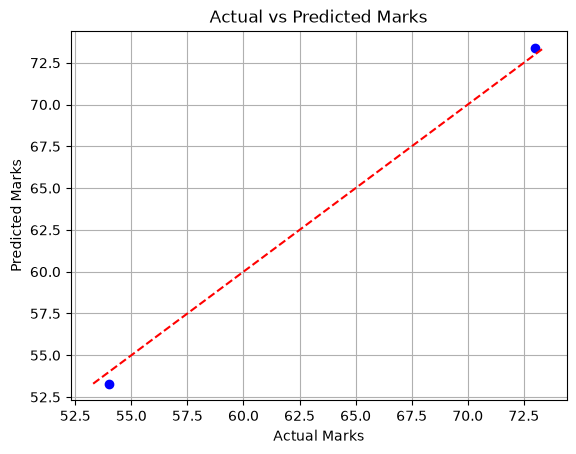

In [19]:
plt.scatter(y_test, y_pred_test, color='blue')
minimum = min(y_test.min(), y_pred_test.min())
maximum = max(y_test.max(), y_pred_test.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color='red',
    linestyle='--'
)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.grid(True)
plt.show()

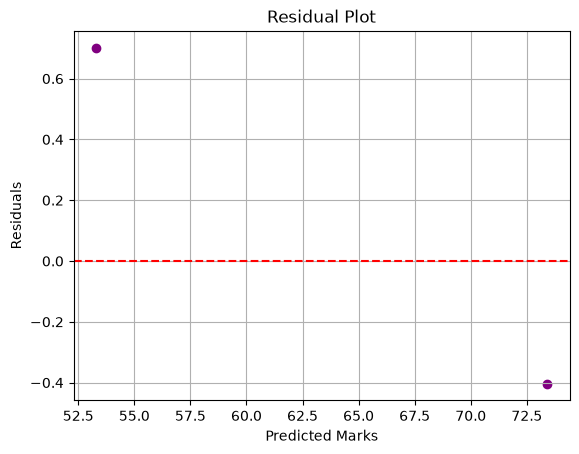

In [20]:
resudal = y_test - y_pred_test
plt.scatter(y_pred_test, resudal, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Marks")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

In [24]:
model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](3,)","[ 5.5,77.5,68. ]"


In [25]:
for alpha in [0.01, 0.1, 1, 10, 100]:
    model = Ridge(alpha=alpha)
    model.fit(x_train, y_train)

In [26]:
from sklearn.linear_model import RidgeCV

model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)

model.fit(x_train, y_train)
print("Best alpha:", model.alpha_)

Best alpha: 0.01


c:\Users\bda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\bda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\bda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\bda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\bda\AppData\Local\Python\pythoncore-3.14-64\Lib\sit